# MediCare : Patient Follow-Up Agent
### Agentic AI with **LangGraph**

## 0 · Setup — install, imports, API key

In [26]:
!pip install -q langgraph langchain-google-genai langchain-core pandas matplotlib fastapi "httpx<0.28"

In [62]:
import os, json, getpass
import pandas as pd
import matplotlib.pyplot as plt

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage

# --- Gemini API key ---
API_KEY = None
try:
    from google.colab import userdata
    API_KEY = userdata.get('GEMINI_API_KEY')
except Exception:
    API_KEY = os.getenv('GEMINI_API_KEY')
if not API_KEY:
    API_KEY = getpass.getpass('Enter your Gemini API key: ')
API_KEY = API_KEY.strip()

MODEL = 'gemini-flash-lite-latest'
llm = ChatGoogleGenerativeAI(
    model=MODEL,
    temperature=0,
    google_api_key=API_KEY,
    transport='rest',
    max_retries=2,
    timeout=60,
)

print('ready · model:', MODEL, '· key: ****' + API_KEY[-4:])
print('test:', llm.invoke('say hi in 3 words').content)


ready · model: gemini-flash-lite-latest · key: ****wltQ
test: [{'type': 'text', 'text': 'Hello to you!', 'extras': {'signature': 'El4KXAFpFH0T7/sk3ox3yzipbJc7xeH6qWYNzPhOfXxpr4wNj5kqjnhmTOSGU5y5i3KU2x2IdvzNKb/7qoGpde0TylqE3cfNmETH9IoXgkxwdC5WvzsApNmsRpdHtC0e'}}]


In [64]:
# Upload the dataset  — or place patient_data.csv next to this notebook
if not os.path.exists('patient_data.csv'):
    try:
        from google.colab import files
        print('Please upload patient_data.csv ...'); files.upload()
    except Exception:
        raise FileNotFoundError('patient_data.csv not found — upload it and re-run this cell.')
print('CSV present:', os.path.exists('patient_data.csv'))

CSV present: True


## Task 1 · Data Loading & Exploratory Analysis
Load the 100-patient snapshot, type the columns, and derive the fields the follow-up logic needs:
`missed_last_appointment` (bool) and an `overdue` flag (next visit already before the cohort's
most recent visit date).

In [65]:
NUMERIC = ['age','lab_value','days_since_last_visit','vitals_bp_systolic',
           'vitals_bp_diastolic','vitals_heart_rate','vitals_spo2']
DATES = ['last_visit_date','next_scheduled_visit']

def load_patients(path='patient_data.csv'):
    df = pd.read_csv(path)
    for c in NUMERIC: df[c] = pd.to_numeric(df[c], errors='coerce')
    for c in DATES:   df[c] = pd.to_datetime(df[c], errors='coerce')
    df['missed_last_appointment'] = (df['missed_last_appointment'].astype(str)
                                     .str.strip().str.lower().eq('yes'))
    as_of = df['last_visit_date'].max()
    df['overdue'] = df['next_scheduled_visit'] < as_of
    df.attrs['as_of'] = as_of
    return df

df = load_patients()
print(f"Rows: {len(df)}  |  Columns: {df.shape[1]}  |  Snapshot as-of: {df.attrs['as_of'].date()}")
df.head()

Rows: 100  |  Columns: 19  |  Snapshot as-of: 2024-10-27


,patient_id,patient_name,age,gender,diagnosis,current_medication,lab_test,lab_value,lab_unit,last_visit_date,next_scheduled_visit,days_since_last_visit,missed_last_appointment,vitals_bp_systolic,vitals_bp_diastolic,vitals_heart_rate,vitals_spo2,notes,overdue
0,P0001,Aarav Sharma,68,Male,Type 2 Diabetes,Metformin 500mg,HbA1c,9.9,%,2024-04-24,2024-06-08,251,False,174,70,95,96,Patient reports good medication adherence.,True
1,P0002,Priya Patel,29,Male,Heart Failure,Furosemide 40mg,BNP,317.6,pg/mL,2024-01-14,2024-02-28,352,False,174,91,72,97,Patient reports no new symptoms.,True
2,P0003,Rohan Mehta,45,Male,"Type 2 Diabetes, CKD","Insulin Glargine 10U, Losartan 50mg",HbA1c,11.4,%,2024-08-04,2024-10-03,149,False,132,86,64,91,Medication dose adjusted this visit.,True
3,P0004,Anjali Singh,34,Female,"COPD, Heart Failure","Tiotropium 18mcg, Furosemide 40mg",FEV1%,33.8,%,2024-01-23,2024-04-22,343,False,153,70,93,94,Patient reports no new symptoms.,True
4,P0005,Vikram Nair,51,Male,"Hypertension, Heart Failure","Amlodipine 5mg, Furosemide 40mg",BP Systolic,124.9,mmHg,2024-04-26,2024-06-25,249,False,134,71,82,94,Patient education provided on diet and lifestyle.,True


In [66]:
overview = {
    'n_patients': int(len(df)),
    'age_mean': round(float(df['age'].mean()), 1),
    'age_range': [int(df['age'].min()), int(df['age'].max())],
    'gender_counts': df['gender'].value_counts().to_dict(),
    'n_missed_appointments': int(df['missed_last_appointment'].sum()),
    'n_overdue': int(df['overdue'].sum()),
    'mean_days_since_visit': round(float(df['days_since_last_visit'].mean()), 1),
}
print(json.dumps(overview, indent=2))

{
  "n_patients": 100,
  "age_mean": 55.4,
  "age_range": [
    28,
    82
  ],
  "gender_counts": {
    "Male": 53,
    "Female": 47
  },
  "n_missed_appointments": 15,
  "n_overdue": 81,
  "mean_days_since_visit": 211.4
}


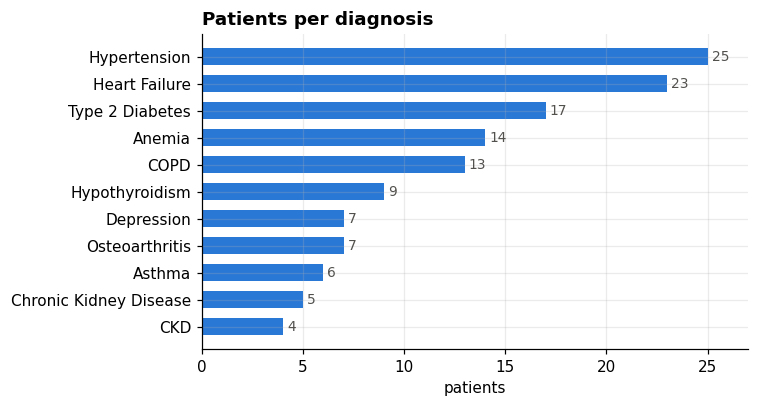

In [67]:
dx = df['diagnosis'].str.split(',').explode().str.strip().value_counts()
plt.rcParams.update({'figure.dpi':110,'axes.spines.top':False,'axes.spines.right':False,
                     'axes.grid':True,'grid.alpha':.25,'font.size':10})
fig, ax = plt.subplots(figsize=(7,3.8))
ax.barh(dx.index[::-1], dx.values[::-1], color='#2a78d6', height=.62)
for i,v in enumerate(dx.values[::-1]): ax.text(v+.2, i, str(v), va='center', fontsize=9, color='#52514e')
ax.set_title('Patients per diagnosis', loc='left', fontweight='bold'); ax.set_xlabel('patients')
ax.margins(x=.08); plt.tight_layout(); plt.show()

In [68]:
missed = df[df['missed_last_appointment']][['patient_id','patient_name','age','diagnosis',
          'lab_test','lab_value','days_since_last_visit']].reset_index(drop=True)
print(f"{len(missed)} patients missed their last appointment:")
missed

15 patients missed their last appointment:


,patient_id,patient_name,age,diagnosis,lab_test,lab_value,days_since_last_visit
0,P0018,Lakshmi Menon,36,Heart Failure,BNP,952.3,157
1,P0031,Harish Bajaj,68,Chronic Kidney Disease,eGFR,52.1,147
2,P0036,Vandana Srivastava,71,Type 2 Diabetes,HbA1c,6.2,274
3,P0041,Tarun Mukherjee,46,Hypertension,BP Systolic,171.4,245
4,P0043,Gaurav Dey,69,"Hypertension, Anemia",BP Systolic,163.8,311
5,P0058,Hina Akhtar,45,Heart Failure,BNP,913.0,171
6,P0062,Mary Joseph,35,Asthma,Peak Flow,224.2,271
7,P0063,John Fernandez,66,Hypertension,BP Systolic,172.4,249
8,P0066,Angela Pereira,37,"Type 2 Diabetes, CKD",HbA1c,10.1,322
9,P0069,Victor Lobo,58,Type 2 Diabetes,HbA1c,6.9,221


## Task 2 · Define the Agent's Tools
Four tools, declared with LangChain's `@tool` decorator (the docstring + type hints become the
schema Gemini sees). They return **data and objective evidence**, never a decision —
`compute_risk_indicators` compares each lab to a clinical reference range and checks vitals +
engagement, but **priority and actions stay Gemini's call**.

In [69]:
# Clinical reference ranges — facts, not decisions.
# (concern_direction, moderate_threshold, severe_threshold); 'high' = bigger is worse.
LAB_REFERENCE = {
    'HbA1c':('high',7.0,9.0),   'BNP':('high',100.0,400.0), 'eGFR':('low',60.0,30.0),
    'FEV1%':('low',50.0,30.0),  'BP Systolic':('high',140.0,180.0),
    'Hemoglobin':('low',11.0,8.0), 'Pain Score':('high',4.0,7.0),
    'PHQ-9 Score':('high',10.0,20.0), 'TSH':('high',4.5,10.0), 'Peak Flow':('low',400.0,250.0),
}
def _classify(direction, value, moderate, severe):
    if direction == 'high':
        return 'severe' if value>=severe else 'moderate' if value>=moderate else 'normal'
    return 'severe' if value<=severe else 'moderate' if value<=moderate else 'normal'

def _record(pid):
    row = df[df['patient_id'] == pid]
    if row.empty: return {'error': f'patient {pid} not found'}
    rec = row.iloc[0].to_dict()
    for k,v in rec.items():
        if isinstance(v, pd.Timestamp): rec[k] = None if pd.isna(v) else v.date().isoformat()
        elif pd.isna(v): rec[k] = None
        elif hasattr(v,'item'): rec[k] = v.item()
    return rec

ACTION_PLANS = []      # save_action_plan writes the agent's decisions here

@tool
def get_patient(patient_id: str) -> dict:
    """Fetch the full clinical record for one patient by id."""
    return _record(patient_id)

@tool
def compute_risk_indicators(patient_id: str) -> dict:
    """Return OBJECTIVE clinical risk evidence (abnormal labs/vitals, missed or overdue visits)
    for a patient. Evidence only — YOU decide the priority."""
    p = _record(patient_id)
    if 'error' in p: return p
    flags = []
    ref = LAB_REFERENCE.get(p['lab_test'])
    if ref and p['lab_value'] is not None:
        lvl = _classify(ref[0], p['lab_value'], ref[1], ref[2])
        if lvl != 'normal':
            flags.append({'type':'lab','metric':p['lab_test'],'value':p['lab_value'],'concern':lvl})
    if p['vitals_spo2'] is not None and p['vitals_spo2'] < 92:
        flags.append({'type':'vital','metric':'SpO2','value':p['vitals_spo2'],
                      'concern':'severe' if p['vitals_spo2']<90 else 'moderate'})
    if p['vitals_bp_systolic'] is not None and p['vitals_bp_systolic'] >= 180:
        flags.append({'type':'vital','metric':'BP systolic','value':p['vitals_bp_systolic'],'concern':'severe'})
    hr = p['vitals_heart_rate']
    if hr is not None and (hr < 60 or hr > 100):
        flags.append({'type':'vital','metric':'heart rate','value':hr,'concern':'moderate'})
    if p['missed_last_appointment']:
        flags.append({'type':'engagement','metric':'missed_last_appointment','value':True,'concern':'moderate'})
    if p['days_since_last_visit'] is not None and p['days_since_last_visit'] > 180:
        flags.append({'type':'engagement','metric':'days_since_last_visit',
                      'value':p['days_since_last_visit'],'concern':'moderate'})
    return {'patient_id':patient_id,'diagnosis':p['diagnosis'],'n_flags':len(flags),'evidence':flags}

@tool
def list_missed_appointments() -> dict:
    """List the ids of patients who missed their last appointment."""
    sub = df[df['missed_last_appointment']]
    return {'count': int(len(sub)), 'patients': sub['patient_id'].tolist()}

@tool
def save_action_plan(patient_id: str, priority: str, actions: list[str], rationale: str) -> dict:
    """Record your final follow-up decision for a patient: priority (High/Medium/Low),
    2-4 concrete actions, and a one-line clinical rationale."""
    plan = {'patient_id':patient_id,'priority':priority,'actions':actions,'rationale':rationale}
    ACTION_PLANS.append(plan)
    return {'status':'saved', **plan}

TOOLS = [get_patient, compute_risk_indicators, list_missed_appointments, save_action_plan]
print('Tools:', [t.name for t in TOOLS])
print(json.dumps(compute_risk_indicators.invoke({'patient_id':'P0008'}), indent=2))

Tools: ['get_patient', 'compute_risk_indicators', 'list_missed_appointments', 'save_action_plan']
{
  "patient_id": "P0008",
  "diagnosis": "Heart Failure",
  "n_flags": 2,
  "evidence": [
    {
      "type": "lab",
      "metric": "BNP",
      "value": 1100.1,
      "concern": "severe"
    },
    {
      "type": "engagement",
      "metric": "days_since_last_visit",
      "value": 204,
      "concern": "moderate"
    }
  ]
}


## Task 3 · Agentic Loop as a LangGraph `StateGraph`
Two nodes and one conditional edge:

```
        ┌─────────┐   tool calls?  ┌────────┐
START ─▶│  agent  │───── yes ─────▶│ tools  │
        │ (Gemini)│◀───────────────│(ToolNode)
        └─────────┘                └────────┘
             │ no (done)
             ▼
            END
```

`tools_condition` inspects the agent's last message: if it contains tool calls, route to the
`tools` node (which runs them and appends results); otherwise finish. State is the message list.

In [70]:
llm_with_tools = llm.bind_tools(TOOLS)

def agent_node(state: MessagesState):
    """The Gemini agent: reads the running message list, returns its next move."""
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build & compile the graph
builder = StateGraph(MessagesState)
builder.add_node("agent", agent_node)
builder.add_node("tools", ToolNode(TOOLS))
builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", tools_condition)   # -> "tools" or END
builder.add_edge("tools", "agent")
graph_app = builder.compile()

SYSTEM_PROMPT = (
    "You are a clinical care-coordination agent for MediCare Clinic, an outpatient facility "
    "managing chronic-disease patients (Type 2 Diabetes, Hypertension, Heart Failure, COPD, CKD, "
    "Anemia, and others). Autonomously review patient records, judge who is at clinical risk, and "
    "produce a prioritised follow-up plan. Use the tools to gather evidence first. "
    "compute_risk_indicators returns objective findings — weigh them with clinical judgement; the "
    "priority and actions are YOUR decision. For every patient you assess, call save_action_plan "
    "exactly once with a priority (High/Medium/Low), 2-4 concrete actions, and a one-line rationale. "
    "When finished, give a short summary."
)

def run_agent(task, max_steps=40):
    """Run the graph for a task; return the final text, tool trace, and saved plans."""
    ACTION_PLANS.clear()
    out = graph_app.invoke(
        {"messages": [SystemMessage(SYSTEM_PROMPT), HumanMessage(task)]},
        config={"recursion_limit": max_steps})
    for m in out["messages"]:
        if isinstance(m, ToolMessage):
            r = json.loads(m.content) if m.content.startswith('{') else {}
            print(f"  → {m.name}  ⇒  {r.get('n_flags', r.get('count', r.get('status','')))}")
    return {"final": out["messages"][-1].content, "action_plans": list(ACTION_PLANS)}

try:
    print(graph_app.get_graph().draw_ascii())
except Exception:
    print("graph nodes:", list(graph_app.get_graph().nodes))

graph nodes: ['__start__', 'agent', 'tools', '__end__']


## Task 4 · Single-Patient Analysis
Invoke the graph on one patient. Gemini fetches the record, computes risk evidence, then **decides**
a priority + action plan and saves it. The tool trace prints live.

In [46]:
result4 = run_agent("Assess patient P0008. Gather their record and risk indicators, then decide "
                    "their follow-up priority and actions, and save the plan.")
print('\n Agent summary:', result4['final'])
print('\n Action plan:'); print(json.dumps(result4['action_plans'], indent=2))

  → get_patient  ⇒  
  → compute_risk_indicators  ⇒  2
  → save_action_plan  ⇒  saved

 Agent summary: [{'type': 'text', 'text': '### Patient Assessment Summary'}, {'type': 'text', 'text': ': Deepa Krishnan (P0008)\n\n- **Demographics & Primary Diagnosis:** 45-year-old male with Heart Failure.\n- **Current Regimen:** Furosemide 40 mg daily.\n- **Key Clinical Findings:**\n  - **Markedly Elevated BNP:** 1,100.1 pg/mL (indicative of acute/worsening cardiac stress/decompensation).\n  - **Abnormal Vitals:** BP 155/106 mmHg (uncontrolled Stage 2 hypertension), SpO2 92% (borderline hypoxemia), HR 87 bpm.\n  - **Symptoms:** Reporting dizziness and fatigue.\n  - **Care Engagement:** Overdue for follow-up (last seen 204 days ago; missed scheduled July 2024 appointment).\n\n---\n\n### Follow-up Decision & Action Plan\n\n- **Assigned Priority:** **High**\n- **Clinical Rationale:** Severely elevated BNP (1,100.1 pg/mL), uncontrolled Stage 2 hypertension (155/106 mmHg), borderline low SpO2 (92%), sy

## Task 5 · Missed-Appointment Follow-Up
The agent finds everyone who missed their last appointment, assesses each, and produces a
prioritised plan per patient — the worklist the care-coordination team needs.

In [71]:
result5 = run_agent("Use list_missed_appointments to find patients who missed their last "
                    "appointment, then assess the first 5 of them and save a prioritised action "
                    "plan for each.", max_steps=80)
plans = pd.DataFrame(result5['action_plans'])
plans['name'] = plans['patient_id'].map(df.set_index('patient_id')['patient_name'])
plans['actions'] = plans['actions'].apply(lambda a: ' · '.join(a))
print('\n Agent summary:', result5['final'])
plans[['patient_id','name','priority','rationale','actions']]

  → list_missed_appointments  ⇒  15
  → get_patient  ⇒  
  → compute_risk_indicators  ⇒  2
  → get_patient  ⇒  
  → compute_risk_indicators  ⇒  2
  → get_patient  ⇒  
  → compute_risk_indicators  ⇒  3
  → get_patient  ⇒  
  → compute_risk_indicators  ⇒  5
  → get_patient  ⇒  
  → compute_risk_indicators  ⇒  3
  → save_action_plan  ⇒  saved
  → save_action_plan  ⇒  saved
  → save_action_plan  ⇒  saved
  → save_action_plan  ⇒  saved
  → save_action_plan  ⇒  saved

 Agent summary: [{'type': 'text', 'text': 'Successfully assessed the first 5 patients who missed their appointments and saved prioritized action plans for each:\n\n1. **P0018 (Lakshmi Menon)** - **High Priority**: Heart failure with severely elevated BNP (952.3 pg/mL) and missed follow-up.\n2. **P0031 (Harish Bajaj)** - **Medium Priority**: Chronic Kidney Disease with moderate renal impairment (eGFR 52.1) and elevated diastolic BP (99 mmHg).\n3. **P0036 (Vandana Srivastava)** - **High Priority**: Type 2 Diabetes with dangerousl

,patient_id,name,priority,rationale,actions
0,P0018,Lakshmi Menon,High,Severe BNP elevation and uncontrolled heart fa...,Contact patient urgently regarding heart failu...
1,P0036,Vandana Srivastava,High,Dangerously high systolic blood pressure combi...,Contact patient urgently to address severe sys...
2,P0031,Harish Bajaj,Medium,Stage 3 CKD with moderate renal impairment and...,Contact patient to reschedule missed appointme...
3,P0043,Gaurav Dey,High,Uncontrolled hypertension and anemia with over...,Contact patient to reschedule overdue visit an...
4,P0041,Tarun Mukherjee,High,Borderline SpO2 (90%) and severe hypertension ...,Contact patient urgently regarding SpO2 of 90%...


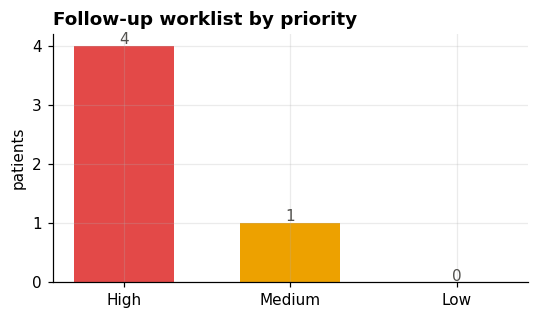

In [72]:
order = ['High','Medium','Low']
counts = plans['priority'].value_counts().reindex(order).fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(5,3))
ax.bar(order, counts.values, color=['#e34948','#eda100','#008300'], width=.6)
for i,v in enumerate(counts.values): ax.text(i, v+.03, str(v), ha='center', fontsize=10, color='#52514e')
ax.set_title('Follow-up worklist by priority', loc='left', fontweight='bold'); ax.set_ylabel('patients')
plt.tight_layout(); plt.show()

## FastAPI REST API (email mandate)
The same LangGraph agent, exposed over HTTP. Read-only endpoints return patient data and risk
evidence; the `/agent/*` endpoint runs the graph on demand. Exercised in-process with FastAPI's
`TestClient` (no server needed in Colab).

In [73]:
from fastapi import FastAPI, HTTPException
from fastapi.testclient import TestClient

app = FastAPI(title='MediCare Patient Follow-Up Agent (LangGraph)', version='1.0.0')

@app.get('/health')
def health(): return {'status':'ok','model':MODEL,'framework':'langgraph','patients':int(len(df))}

@app.get('/patients')
def list_patients(limit: int = 10):
    cols = ['patient_id','patient_name','age','gender','diagnosis','missed_last_appointment']
    return {'patients': df[cols].head(limit).to_dict(orient='records')}

@app.get('/patients/{patient_id}/risk')
def patient_risk(patient_id: str):
    rec = compute_risk_indicators.invoke({'patient_id': patient_id})
    if 'error' in rec: raise HTTPException(404, rec['error'])
    return rec

@app.post('/agent/analyze/{patient_id}')
def analyze(patient_id: str):
    res = run_agent(f'Assess patient {patient_id} and save a follow-up plan.')
    return {'patient_id':patient_id,'summary':res['final'],'action_plans':res['action_plans']}

api = TestClient(app)
print('GET /health              ->', api.get('/health').json())
print('GET /patients?limit=2    ->', api.get('/patients', params={'limit':2}).json())
print('GET /patients/P0008/risk ->')
print(json.dumps(api.get('/patients/P0008/risk').json(), indent=2))

GET /health              -> {'status': 'ok', 'model': 'gemini-flash-lite-latest', 'framework': 'langgraph', 'patients': 100}
GET /patients?limit=2    -> {'patients': [{'patient_id': 'P0001', 'patient_name': 'Aarav Sharma', 'age': 68, 'gender': 'Male', 'diagnosis': 'Type 2 Diabetes', 'missed_last_appointment': False}, {'patient_id': 'P0002', 'patient_name': 'Priya Patel', 'age': 29, 'gender': 'Male', 'diagnosis': 'Heart Failure', 'missed_last_appointment': False}]}
GET /patients/P0008/risk ->
{
  "patient_id": "P0008",
  "diagnosis": "Heart Failure",
  "n_flags": 2,
  "evidence": [
    {
      "type": "lab",
      "metric": "BNP",
      "value": 1100.1,
      "concern": "severe"
    },
    {
      "type": "engagement",
      "metric": "days_since_last_visit",
      "value": 204,
      "concern": "moderate"
    }
  ]
}


In [74]:
# Live agent endpoint (runs the LangGraph agent via Gemini):
r = api.post('/agent/analyze/P0018')
print(json.dumps(r.json(), indent=2))

  → get_patient  ⇒  
  → compute_risk_indicators  ⇒  2
  → save_action_plan  ⇒  saved
{
  "patient_id": "P0018",
  "summary": [
    {
      "type": "text",
      "text": "### Assessment Summary: Patient P0018 (Lakshmi Menon)\n\n* **Diagnosis:** Heart Failure\n* **Clinical Findings:** \n  * Severely elevated BNP: **952.3 pg/mL**\n  * Uncontrolled Hypertension: **160/87 mmHg**\n  * Engagement: Missed last appointment, **157 days overdue** for visit.\n* **Assigned Priority:** **High**\n* **Action Plan Saved:**\n  1. Contact patient immediately to schedule an urgent cardiology follow-up visit.\n  2. Escalate to the attending cardiologist for possible diuretic adjustment (Furosemide).\n  3. Instruct patient on daily weight monitoring and red-flag symptom reporting.",
      "extras": {
        "signature": "El4KXAFpFH0TDl67wXqO9/XrI0m7GgZhNX//5xlgG1iskmgsIEjGH9KUA4mh1zUBCqR64U3GIqZuIFipPgWDWJxylteNsSwe5oRIMJMfdti8wbpAWTEWt0a/zW0Hyrj9"
      }
    }
  ],
  "action_plans": [
    {
      "patie

## Notes — architecture & mandates

- **Agentic AI (LangGraph):** the agent is a `StateGraph` — `agent` (Gemini) ⇄ `tools` (`ToolNode`)
  with a `tools_condition` edge that loops until the model stops calling tools. Production-standard,
  fully inspectable (see the ASCII graph above).
- **LLM decides, nothing hard-coded:** tools return evidence; Gemini chooses risk, priority, actions.
- **Modular coding:** reusable `load_patients`, `@tool` functions, `run_agent`, and the FastAPI app
  share one implementation.
- **FastAPI:** REST API defined above, demonstrated with `TestClient`.
- **Model:** `gemini-3.6-flash` via `langchain-google-genai` (swap `MODEL` for `gemini-2.5-flash`/`-pro`);
  `temperature=0` for reproducibility.
- **Talking point:** LangGraph gives durable state, checkpointing, and easy branching / multi-agent
  extension — the right tool when the agent graph grows beyond a single linear loop.

Gemini API key:   https://aistudio.google.com/apikey